# Executive Brief Assistant  
Authors:  
 - [Lior Gazit](https://www.linkedin.com/in/liorgazit).  
 - [Meysam Ghaffari](https://www.linkedin.com/in/meysam-ghaffari-ph-d-a2553088/).  

This Colab notebook is referenced in our book's Github repo:   
https://github.com/PacktPublishing/Mastering-NLP-From-Foundations-to-Agents-Second-Edition   
<a target="_blank" href="https://colab.research.google.com/github/PacktPublishing/Mastering-NLP-From-Foundations-to-Agents-Second-Edition/blob/main/Chapter11_notebooks/Ch11_Executive_Brief_Assistant.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook is taught and reviewed in our book:  
**[Mastering NLP from Foundations to Agents](https://www.amazon.com/Mastering-NLP-Foundations-Agents-Automation/dp/1806106132)**  
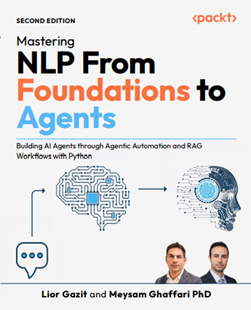



**The purpose of this notebook:**  
Given a local folder of documents (PDF, HTML, TXT/MD), produce a **1‑page executive brief**: bullet summaries, key metrics, and **inline citations**, followed by a **risk note** approved by a **policy agent**.

This notebook has two parts:
1) **Single‑agent baseline** — one agent does:  
 retrieval → draft → self‑critique → citation‑check → stop when: evidence coverage ≥ threshold  
2) **Multi‑agent hub‑and‑spoke** — Coordinator, Researcher, Analyst, Auditor, Editor, Policy gate.  
 Agents coordinate via a shared **blackboard** and are instrumented with **cost/tokens/latency**.  

It uses **LLMPop** for model spin‑up. Defaults to a small API model for quick, low‑cost runs on free Colab.  

How to use this notebook:  
1. Upload a few small PDFs/HTML/TXT under `/content/docs` (a handful of 1–5 page files is enough on free Colab).
2. Set `OPENAI_API_KEY` (recommended) or rely on the mock client for structure-only runs.
3. Re‑run **Ingest**; then re‑run **baseline** and **multi‑agent** cells.
4. Tune knobs:
   * Retrieval: `k`, `CHUNK_SIZE`, `CHUNK_OVERLAP`
   * Checks: `citation_checker` threshold, `coverage_threshold`
   * Budgets: `max_steps`, `max_seconds`
5. Export: copy the final brief text from the printout or adapt to save as Markdown/PDF.

**Requirements:**  
* When running in Colab, use this runtime notebook setting: `Python 3, T4 GPU`  
* Set an OpenAI API key only if you choose an OpenAI model (optional in this notebook).

>*```Disclaimer: The content and ideas presented in this notebook are solely those of the authors and do not represent the views or intellectual property of the authors' employers.```*

**Installing:**

In [ ]:
%pip -q install llmpop sentence-transformers faiss-cpu pymupdf beautifulsoup4 tiktoken > /dev/null
from llmpop import install_ollama_deps
install_ollama_deps()

Installing system dependencies for Ollama: zstd, pciutils


**Imports:**

In [ ]:
import os, time, re, json, math, glob, shutil, textwrap, requests
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional, Tuple
import pandas as pd

# Embeddings / vector store
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# Parsers
import fitz  # PyMuPDF
from bs4 import BeautifulSoup

# Token est.
import tiktoken

# LLM setup via LLMPop (init_llm)
from getpass import getpass
from llmpop import init_llm
from langchain_core.messages import SystemMessage, HumanMessage

**Initial settings and LLM choice:**

In [ ]:
# Choose model via env VARS (PROVIDER_NAME, LLMPOP_MODEL) or default:
PROVIDER_NAME = os.environ.get("LLMPOP_PROVIDER", "openai")  # the options here are: "ollama" or "openai"
MODEL_NAME = os.environ.get("LLMPOP_MODEL", "gpt-5.2-2025-12-11")  # the options here are any model from OpenAI or Ollama: "gpt-5.2-2025-12-11", "llama3.2:1b", ...

In [ ]:
if PROVIDER_NAME == "openai":
  os.environ["OPENAI_API_KEY"] = getpass("Paste your OpenAI API key: ")

# Build a LangChain ChatModel using LLMPop
# Note: If you set allow_paid_models=False and choose an OpenAI model, calls will error.
_llm_core = init_llm(model=MODEL_NAME, provider=PROVIDER_NAME, temperature=0.0, verbose=True)

Paste your OpenAI API key: ··········
🚀 Setting up remote OpenAI chat model…
Installing langchain-openai...
All done setting up OpenAI (ChatOpenAI).



In [ ]:
# Simple adapter so downstream code can call .chat(messages=[{role, content}, ...]):
class LLMAdapter:
    def __init__(self, chatmodel):
        self.chatmodel = chatmodel
    def chat(self, messages, **k):
        lc_msgs = []
        for m in messages:
            role = m.get("role", "user")
            if role == "system":
                lc_msgs.append(SystemMessage(content=m.get("content", "")))
            else:
                lc_msgs.append(HumanMessage(content=m.get("content", "")))
        resp = self.chatmodel.invoke(lc_msgs)
        return getattr(resp, "content", str(resp))

_llm = LLMAdapter(_llm_core)
print("LLM ready →", MODEL_NAME)

LLM ready → gpt-5.2-2025-12-11


**Helper functions:**

In [ ]:
# Colab-safe replacement for caas_jupyter_tools.display_dataframe_to_user
def display_dataframe_to_user(name: str, dataframe):
    from IPython.display import display, HTML
    try:
        # Nice table formatting in Colab, if available
        from google.colab import data_table
        data_table.enable_dataframe_formatter()
    except Exception:
        pass
    display(HTML(f"<h4>{name}</h4>"))
    display(dataframe)

## 1. Utilities: token/cost meters, logging, and prompts
Setting up all the classes and functions.

In [ ]:
@dataclass
class Meter:
    model: str
    provider: str
    # If left as None, we'll set sensible defaults in __post_init__ based on provider
    input_cost_per_1k: Optional[float] = None
    output_cost_per_1k: Optional[float] = None
    total_tokens_in: int = 0
    total_tokens_out: int = 0
    total_cost: float = 0.0
    timings: List[Tuple[str, float]] = field(default_factory=list)

    def __post_init__(self):
        # Choose defaults by provider if user didn't pass explicit costs
        if self.input_cost_per_1k is None or self.output_cost_per_1k is None:
            if (self.provider or "").lower() == "ollama":
                # Local models → $0 token cost
                self.input_cost_per_1k = 0.0
                self.output_cost_per_1k = 0.0
            else:
                # Default to OpenAI-like placeholders (adjust if you want model-specific rates)
                self.input_cost_per_1k = 0.00025  # GPT-5 mini input cost
                self.output_cost_per_1k = 0.002  # GPT-5 mini output cost

    def enc(self):
        try:
            return tiktoken.encoding_for_model(self.model)
        except Exception:
            return tiktoken.get_encoding("cl100k_base")

    def count_tokens(self, text: str) -> int:
        return len(self.enc().encode(text or ""))

    def log_call(self, name: str, prompt: str, output: str, dt: float):
        tin = self.count_tokens(prompt)
        tout = self.count_tokens(output)
        self.total_tokens_in += tin
        self.total_tokens_out += tout
        self.total_cost += (tin/1000.0)*self.input_cost_per_1k + (tout/1000.0)*self.output_cost_per_1k
        self.timings.append((name, dt))

    def snapshot(self) -> Dict[str, Any]:
        return {
            "model": self.model,
            "tokens_in": self.total_tokens_in,
            "tokens_out": self.total_tokens_out,
            "cost_usd": round(self.total_cost, 4),
            "steps": len(self.timings),
            "durations": self.timings,
        }


# Simple wrapper over an LLM to unify chat calls + metering
class LLMWrapper:
    def __init__(self, llm_obj, model_name: str):
        self.llm = llm_obj
        self.meter = Meter(model=model_name, provider=PROVIDER_NAME)

    def chat(self, system: str, user: str, **kwargs) -> str:
        messages = [{"role":"system","content":system}, {"role":"user","content":user}]
        t0 = time.time()
        if hasattr(self.llm, "chat"):
            out = self.llm.chat(messages, **kwargs)
        else:
            # LLMPop Chat API: allow llm(messages=[...]) style
            try:
                out = self.llm(messages=messages, **kwargs)
            except Exception:
                # final fallback
                out = str(self.llm)
        dt = time.time() - t0
        self.meter.log_call(kwargs.get("name","chat"), user, out, dt)
        return out

**Instantiate wrapped LLM:**

In [ ]:
LLM = LLMWrapper(_llm, MODEL_NAME)

### Prompts

In [ ]:
SYSTEM_BASE = (
    "You are an Executive Brief Assistant. Be concise, factual, and cite sources inline like [S1], [S2].\n"
    "Prefer bullet points. Extract **metrics** (numbers, dates, percentages) explicitly."
)

PROMPT_DRAFT = textwrap.dedent("""
You are drafting a 1-page executive brief from provided EVIDENCE.
Return:
1) "Key Takeaways" — 5-8 bullets
2) "Key Metrics" — bullet list of numbers & dates with % or units
3) "Details with Inline Citations" — short bullets, each ending with [S#]
Keep total under ~250 words.
EVIDENCE (JSON list of {{id, source, text}}):
{evidence_json}
""")

PROMPT_SELF_CRITIQUE = textwrap.dedent("""
Check the DRAFT for completeness and unsupported claims.
- List missing topics if any.
- Mark any bullet that lacks evidence.
Output JSON: {{"missing_topics": [...], "unsupported": ["...excerpt..."]}}
DRAFT:
{draft}
""")

PROMPT_EDITOR = textwrap.dedent("""
Edit for executive tone, clarity, and brevity.
- Preserve citations like [S#].
- Keep to ~1 page total.
INPUT:
{draft}
""")

PROMPT_POLICY = textwrap.dedent("""
Act as a policy gate. If text mentions **sensitive terms** (investment advice, medical advice, PII, legal directives),
add a short "Risk Note" with safe-language guidance. Else say "No material risk".
TEXT:
{final_text}
""")

## 2. Load & index local documents
Put your files under `/content/docs` (PDF, HTML, TXT/MD).  
**If you do not elect to put files in the folder, the code will default to a use an example file: [ProRL: Prolonged Reinforcement Learning Expands Reasoning Boundaries in Large Language Models](https://arxiv.org/pdf/2505.24864)**

We set each chunk to ~700 chars with 100‑char overlaps.

In [ ]:
DOC_DIR = "/content/docs"
os.makedirs(DOC_DIR, exist_ok=True)

CHUNK_SIZE = 700
CHUNK_OVERLAP = 100

model_embed = SentenceTransformer("all-MiniLM-L6-v2")
index = None
store: List[Dict[str, Any]] = []  # [{"id": int, "source": str, "text": str}]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def _chunks(text: str, size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    text = re.sub(r"\s+", " ", text).strip()
    i = 0
    while i < len(text):
        yield text[i:i+size]
        i += size - overlap


def load_pdf(path: str) -> str:
    doc = fitz.open(path)
    return "\n".join(page.get_text("text") for page in doc)


def load_html(path: str) -> str:
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        soup = BeautifulSoup(f.read(), "html.parser")
    return soup.get_text(" ")


def load_txt(path: str) -> str:
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        return f.read()


def ingest_folder(folder: str = DOC_DIR):
    global index, store

    # Make sure that there is at least one document to work with:
    if not any(os.path.isfile(os.path.join(DOC_DIR, f)) for f in os.listdir(DOC_DIR)):
      # If there are no files in the folder, let's have a default PDF from arXiv:
      sample_pdf_url = "https://arxiv.org/pdf/2505.24864"
      sample_pdf_path = os.path.join(DOC_DIR, "sample.pdf")

      print(f"📥 Downloading sample document from {sample_pdf_url} ...")
      try:
          response = requests.get(sample_pdf_url, timeout=30)
          response.raise_for_status()
          with open(sample_pdf_path, "wb") as f:
              f.write(response.content)
          print(f"✅ Sample PDF saved to {sample_pdf_path}")
      except Exception as e:
          print(f"⚠️ Could not download sample PDF: {e}")

    docs = []
    pid = 1
    for fp in glob.glob(os.path.join(folder, "**/*"), recursive=True):
        if os.path.isdir(fp):
            continue
        ext = os.path.splitext(fp)[1].lower()
        try:
            if ext in [".pdf"]:
                raw = load_pdf(fp)
            elif ext in [".html", ".htm"]:
                raw = load_html(fp)
            else:
                raw = load_txt(fp)
        except Exception:
            continue
        for ch in _chunks(raw):
            store.append({"id": pid, "source": os.path.basename(fp), "text": ch})
            docs.append(ch)
            pid += 1

    # Build FAISS index
    embs = model_embed.encode(docs, convert_to_numpy=True, show_progress_bar=False)
    dim = embs.shape[1]
    idx = faiss.IndexFlatIP(dim)
    faiss.normalize_L2(embs)
    idx.add(embs)
    index = (idx, embs)
    print(f"✅ Ingested {len(docs)} chunks from {len(set(d['source'] for d in store))} files.")
    return True

**Load the documents from the designated folder:**

In [ ]:
ingest_folder(DOC_DIR)

📥 Downloading sample document from https://arxiv.org/pdf/2505.24864 ...
✅ Sample PDF saved to /content/docs/sample.pdf
✅ Ingested 169 chunks from 1 files.


True

### Retrieval helper (top‑k)

In [ ]:
def retrieve(query: str, k: int = 6) -> List[Dict[str, Any]]:
    if index is None:
        return []
    idx, embs = index
    q = model_embed.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q)
    D, I = idx.search(q, k)
    out = []
    for rank, j in enumerate(I[0], 1):
        out.append({
            "id": int(store[j]["id"]),
            "source": store[j]["source"],
            "text": store[j]["text"],
            "score": float(D[0][rank-1])
        })
    return out

## 3. Tools: citation checker & coverage

In [ ]:
NUMERIC_RE = re.compile(r"[-+]?\d[\d,]*(?:\.\d+)?%?")

def citation_checker(claim: str, evidence_chunks: List[Dict[str,Any]], threshold: float = 0.75) -> bool:
    # Guard: no evidence ⇒ cannot verify
    if not claim or not evidence_chunks:
        return False

    # semantic similarity check
    vec_claim = model_embed.encode([claim], convert_to_numpy=True)
    faiss.normalize_L2(vec_claim)

    vec_e = model_embed.encode([c["text"] for c in evidence_chunks], convert_to_numpy=True)
    if vec_e.size == 0:   # extra guard, though not strictly necessary after the first check
        return False
    faiss.normalize_L2(vec_e)

    sims = (vec_claim @ vec_e.T).flatten()
    if sims.max() < threshold:
        return False

    # numeric match heuristic
    nums = NUMERIC_RE.findall(claim)
    if nums:
        best = evidence_chunks[int(np.argmax(sims))]["text"]
        for n in nums:
            if n.replace(",", "") not in best.replace(",", ""):
                return False
    return True


def coverage_score(draft_text: str, evidence_chunks: List[Dict[str,Any]]) -> float:
    # Score = fraction of bullets with a passing citation check
    bullets = [b.strip(" -•\t") for b in draft_text.split("\n") if b.strip().startswith(("-","•"))]
    if not bullets:
        return 0.0
    ok = sum(1 for b in bullets if citation_checker(b, evidence_chunks))
    return ok / max(1, len(bullets))

## 4. Part I — Single‑Agent Baseline

In [ ]:
@dataclass
class SingleAgentConfig:
    k: int = 8
    coverage_threshold: float = 0.6
    max_rounds: int = 2


@dataclass
class SingleAgent:
    llm: LLMWrapper
    cfg: SingleAgentConfig

    def run(self, question: str) -> Dict[str,Any]:
        log = {"question": question, "rounds": []}
        evidence = retrieve(question, k=self.cfg.k)
        evidence_json = json.dumps([{k:v for k,v in e.items() if k!="score"} for e in evidence], ensure_ascii=False)
        draft = self.llm.chat(SYSTEM_BASE, PROMPT_DRAFT.format(evidence_json=evidence_json), name="draft")
        for r in range(self.cfg.max_rounds):
            critique = self.llm.chat(SYSTEM_BASE, PROMPT_SELF_CRITIQUE.format(draft=draft), name="critique")
            try:
                findings = json.loads(critique)
            except Exception:
                findings = {"missing_topics": [], "unsupported": []}
            # If unsupported bullets exist, try to refine by adding more retrieval with missing topics
            add_q = "; ".join(findings.get("missing_topics",[]) or [])
            if add_q:
                evidence += retrieve(add_q, k=4)
                evidence_json = json.dumps([{k:v for k,v in e.items() if k!="score"} for e in evidence], ensure_ascii=False)
                draft = self.llm.chat(SYSTEM_BASE, PROMPT_DRAFT.format(evidence_json=evidence_json), name="redraft")
            cov = coverage_score(draft, evidence)
            log["rounds"].append({"critique": findings, "coverage": cov})
            if cov >= self.cfg.coverage_threshold:
                break
        edited = self.llm.chat(SYSTEM_BASE, PROMPT_EDITOR.format(draft=draft), name="edit")
        policy = self.llm.chat(SYSTEM_BASE, PROMPT_POLICY.format(final_text=edited), name="policy")
        out = {
            "brief": edited,
            "risk_note": policy,
            "evidence": evidence,
            "meter": self.llm.meter.snapshot(),
            "log": log,
        }
        return out

### Run baseline (example)

In [ ]:
if index is None or not store:
    print("⚠️  No documents indexed. Upload files to /content/docs and re-run `ingest_folder()` first.")
else:
    BASELINE_CFG = SingleAgentConfig(k=8, coverage_threshold=0.6, max_rounds=2)
    BASELINE = SingleAgent(LLM, BASELINE_CFG)
    question = "Summarize the key developments and metrics across the documents, focusing on timelines, budgets, and outcomes."
    base_res = BASELINE.run(question)
    print(base_res["brief"])
    print("\nRISK:", base_res["risk_note"])
    print("\nMETER:", base_res["meter"])

## Executive Summary — ProRL Findings

### Key takeaways
- **Performance lift with diminishing returns:** ProRL improves reasoning performance (e.g., **pass@1** and **pass@128**), but many gains occur early and then **saturate on some tasks**. [S49]  
- **Sustained gains on harder benchmarks (especially coding):** More complex tasks show **continued improvement with prolonged RL**, suggesting ProRL helps expand “reasoning boundaries” when broader exploration is required. [S49][S50]  
- **Biggest impact when the base model is weak:** ProRL appears most effective when starting capability is lower; tasks showing minimal gains tend to have **greater overlap with pretraining data** (i.e., **lower creativity index**). [S36][S37][S40]  
- **Monitoring approach:** Training/validation monitoring uses a **blended benchmark set** including **AIME2024, Codeforces, GPQA-diamond, IFEval, and Reasoning Gym (graph_color)** with evaluation-like sampling. [S117]  
- **Early failure mode: instruction/for

## 5. Part II - Multi‑Agent (Hub‑and‑Spoke)
**Agents**: Coordinator → Researcher → Analyst → Auditor → Editor → Policy gate.  
Shared **blackboard** captures snippets & metadata.

In [ ]:
@dataclass
class Blackboard:
    question: str
    evidence: List[Dict[str,Any]] = field(default_factory=list)
    claims: List[Dict[str,Any]] = field(default_factory=list)  # {text, confidence, citations:[S#]}
    draft: str = ""
    final: str = ""
    logs: List[str] = field(default_factory=list)

    def add_log(self, msg):
        ts = time.strftime("%H:%M:%S")
        self.logs.append(f"[{ts}] {msg}")


@dataclass
class Budget:
    max_steps: int = 8
    max_seconds: float = 60


class Coordinator:
    def __init__(self, llm: LLMWrapper, budget: Budget):
        self.llm = llm
        self.budget = budget
    def plan(self, bb: Blackboard) -> List[str]:
        bb.add_log("Coordinator: plan Research → Analyst → Auditor → Editor → Policy")
        return ["research", "analyze", "audit", "edit", "policy"]


class Researcher:
    def __init__(self, k=10):
        self.k = k
    def act(self, bb: Blackboard):
        found = retrieve(bb.question, k=self.k)
        bb.evidence.extend(found)
        bb.add_log(f"Researcher: added {len(found)} chunks")


class Analyst:
    def __init__(self, llm: LLMWrapper):
        self.llm = llm
    def act(self, bb: Blackboard):
        evidence_json = json.dumps([{k:v for k,v in e.items() if k!="score"} for e in bb.evidence], ensure_ascii=False)
        prompt = ("From EVIDENCE, propose 6-9 concise claims with 0-1 numeric metric each. "
                  "Return JSON list of {text, confidence:0-1, cites:[S# indices]}.\nEVIDENCE:\n" + evidence_json)
        out = self.llm.chat(SYSTEM_BASE, prompt, name="claims")
        try:
            bb.claims = json.loads(out)
            bb.add_log(f"Analyst: proposed {len(bb.claims)} claims")
        except Exception:
            bb.claims = []
            bb.add_log("Analyst: failed to parse claims JSON")


class Auditor:
    def act(self, bb: Blackboard):
        passed = []
        for c in bb.claims:
            ok = citation_checker(c.get("text",""), bb.evidence)
            if ok:
                passed.append(c)
        bb.claims = passed
        bb.add_log(f"Auditor: {len(passed)} claims passed citation check")


class Editor:
    def __init__(self, llm: LLMWrapper):
        self.llm = llm

    def act(self, bb: Blackboard):
        # Fallback: if we have no claims, synthesize a draft directly from evidence
        if not bb.claims:
            evidence_json = json.dumps(
                [{k: v for k, v in e.items() if k != "score"} for e in bb.evidence],
                ensure_ascii=False
            )
            draft = self.llm.chat(SYSTEM_BASE, PROMPT_DRAFT.format(evidence_json=evidence_json), name="draft_fallback")
            # Light edit pass for tone/clarity
            draft = self.llm.chat(SYSTEM_BASE, PROMPT_EDITOR.format(draft=draft), name="edit_fallback")
            bb.draft = draft
            bb.add_log("Editor: fallback draft assembled (no claims available)")
            return

        # If we do have claims, format them with any provided cites
        def _fmt_cites(cites):
            try:
                # expects list of integers or strings like ["1","2"]
                ints = [int(c) for c in cites]
                return " " + " ".join(f"[S{i}]" for i in ints) if ints else " [S1]"
            except Exception:
                return " [S1]"

        claims_txt = "\n".join([
            f"- {c.get('text','').strip()}{_fmt_cites(c.get('cites', []))}"
            for c in bb.claims if c.get('text')
        ])

        # Safety: if after filtering nothing remains, fallback to evidence
        if not claims_txt.strip():
            evidence_json = json.dumps(
                [{k: v for k, v in e.items() if k != "score"} for e in bb.evidence],
                ensure_ascii=False
            )
            draft = self.llm.chat(SYSTEM_BASE, PROMPT_DRAFT.format(evidence_json=evidence_json), name="draft_fallback2")
            draft = self.llm.chat(SYSTEM_BASE, PROMPT_EDITOR.format(draft=draft), name="edit_fallback2")
            bb.draft = draft
            bb.add_log("Editor: secondary fallback draft assembled (empty claims after formatting)")
            return

        draft = self.llm.chat(SYSTEM_BASE, PROMPT_EDITOR.format(draft=claims_txt), name="edit2")
        bb.draft = draft
        bb.add_log("Editor: draft assembled from claims")


class PolicyGate:
    def __init__(self, llm: LLMWrapper):
        self.llm = llm
    def act(self, bb: Blackboard):
        note = self.llm.chat(SYSTEM_BASE, PROMPT_POLICY.format(final_text=bb.draft), name="policy2")
        bb.final = bb.draft + "\n\n" + "Risk Note: " + note
        bb.add_log("Policy: risk note appended")


@dataclass
class Orchestrator:
    llm: LLMWrapper
    budget: Budget = field(default_factory=Budget)
    coverage_threshold: float = 0.7

    def run(self, question: str) -> Dict[str,Any]:
        if index is None or not store:
          return {
              "final": "⚠️ No documents indexed. Upload files to /content/docs and re-run ingest_folder() first.",
              "blackboard": {"evidence": [], "claims": [], "logs": ["No docs available"]},
              "meter": self.llm.meter.snapshot(),
          }
        # If there are documents in the folder:
        bb = Blackboard(question=question)
        steps = 0
        t0 = time.time()
        coord = Coordinator(self.llm, self.budget)
        researcher = Researcher(k=12)
        analyst = Analyst(self.llm)
        auditor = Auditor()
        editor = Editor(self.llm)
        policy = PolicyGate(self.llm)

        for stage in coord.plan(bb):
            if time.time() - t0 > self.budget.max_seconds or steps >= self.budget.max_steps:
                bb.add_log("Budget hit → early good‑enough release")
                break
            if stage == "research":
                researcher.act(bb)
            elif stage == "analyze":
                analyst.act(bb)
            elif stage == "audit":
                auditor.act(bb)
            elif stage == "edit":
                editor.act(bb)
                cov = coverage_score(bb.draft, bb.evidence)
                bb.add_log(f"Coverage={cov:.2f}")
                if cov < self.coverage_threshold:
                    # Loop back to research with refined query = top missing metrics
                    bb.add_log("Coverage below threshold → refining query & looping")
                    researcher.act(bb)
                    analyst.act(bb)
                    auditor.act(bb)
                    editor.act(bb)
            elif stage == "policy":
                policy.act(bb)
            steps += 1

        return {
            "final": bb.final or bb.draft,
            "blackboard": {
                "evidence": bb.evidence,
                "claims": bb.claims,
                "logs": bb.logs,
            },
            "meter": self.llm.meter.snapshot(),
        }

### Run multi‑agent orchestration (example)

In [ ]:
ORCH = Orchestrator(LLM, Budget(max_steps=8, max_seconds=60))
ma_res = ORCH.run("Produce an executive brief with metrics, trends, and timelines across the corpus.")
print(ma_res["final"])
print("\nMETER:", ma_res["meter"])

- **Longer RL training increases novelty in reasoning paths**, evidenced by higher **Creativity Index** scores. [S12]  
- **Tasks showing minimal improvement after RL typically have lower Creativity Index scores**, suggesting the base model likely encountered similar examples during pretraining (lower headroom for RL-driven gains). [S40] [S36]

Risk Note: - **No material risk**

METER: {'model': 'gpt-5.2-2025-12-11', 'tokens_in': 16685, 'tokens_out': 5390, 'cost_usd': 0.015, 'steps': 12, 'durations': [('draft', 8.892570495605469), ('critique', 11.265510082244873), ('critique', 10.243178606033325), ('redraft', 9.398274183273315), ('edit', 8.716559648513794), ('policy', 1.1311609745025635), ('claims', 5.4379212856292725), ('draft_fallback', 8.706982612609863), ('edit_fallback', 8.794336080551147), ('claims', 5.414218187332153), ('edit2', 2.012096405029297), ('policy2', 4.317411661148071)]}


## 6. Compare baseline vs multi‑agent (qualitative)
This simple comparison surfaces **coverage**, **cost**, and **latency (per step)** from the meters.  
For a full benchmark, see the chapter’s discussion.


In [ ]:
def meter_to_rows(tag: str, m: Dict[str,Any]):
    dur = sum(t for _,t in m.get("durations", []))
    return {
        "run": tag,
        "tokens_in": m.get("tokens_in",0),
        "tokens_out": m.get("tokens_out",0),
        "cost_usd": m.get("cost_usd",0.0),
        "steps": m.get("steps",0),
        "latency_s": round(dur,2),
    }

if index is None or not store:
    print("⚠️  No documents indexed. Upload files to /content/docs and re-run `ingest_folder()` first.")
else:
    df = pd.DataFrame([
        meter_to_rows("single_agent", base_res["meter"]),
        meter_to_rows("multi_agent", ma_res["meter"]),
    ])

    display_dataframe_to_user("Run comparison (tokens/cost/latency)", df)

,run,tokens_in,tokens_out,cost_usd,steps,latency_s
0,single_agent,6549,3294,0.0082,6,84.33
1,multi_agent,16685,5390,0.0150,12,84.33
